<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/3dto2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

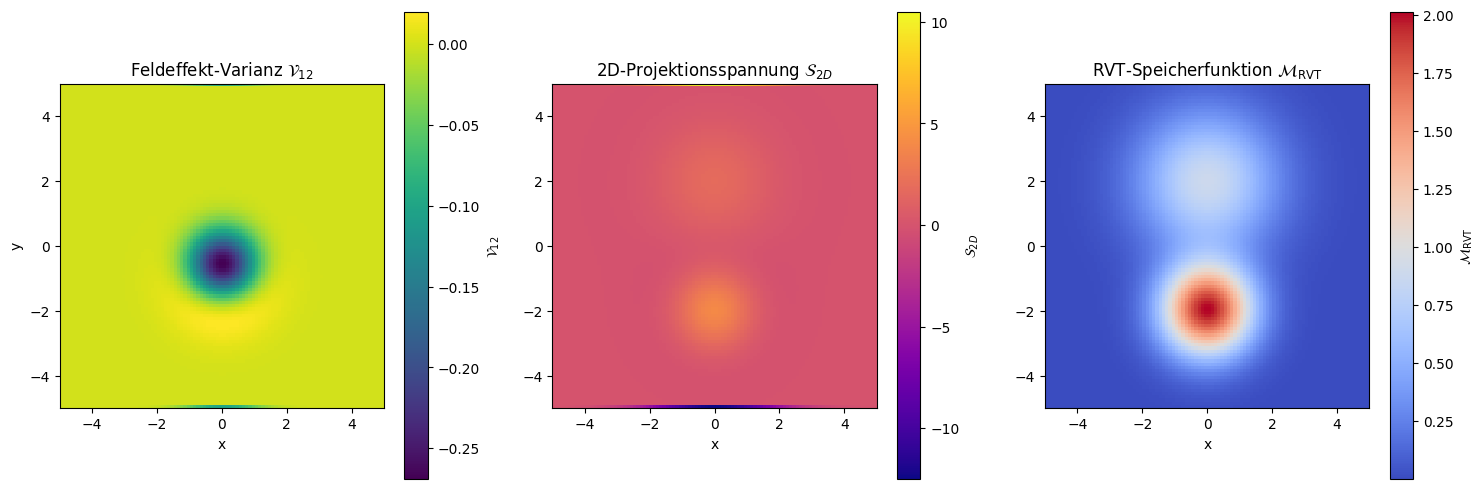

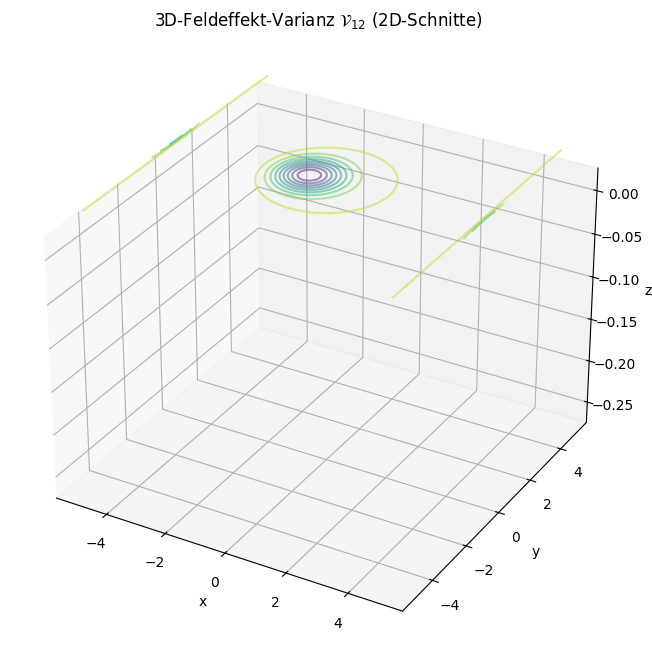

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter

# --- Parameter ---
N = 100  # Gitterpunkte
L = 10.0  # Systemgröße
alpha = 0.8  # Kopplungskonstante (RVT)
chi = 1.0    # Kopplungskonstante für M_RVT

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 (Gauß'sche Verteilungen) ---
Xi_1 = np.exp(-((X + 2)**2 + Y**2 + Z**2) / (2 * 1.0**2))
Xi_2 = np.exp(-((X - 2)**2 + Y**2 + Z**2) / (2 * 1.5**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (z.B. x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$')
plt.xlabel('x')
plt.ylabel('y')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x')

plt.tight_layout()
plt.savefig('RVT_Varianz_Simulation_2D.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurface in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurface für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (2D-Schnitte)')

plt.savefig('RVT_Varianz_3D_Schnitte.png', dpi=300)
plt.show()

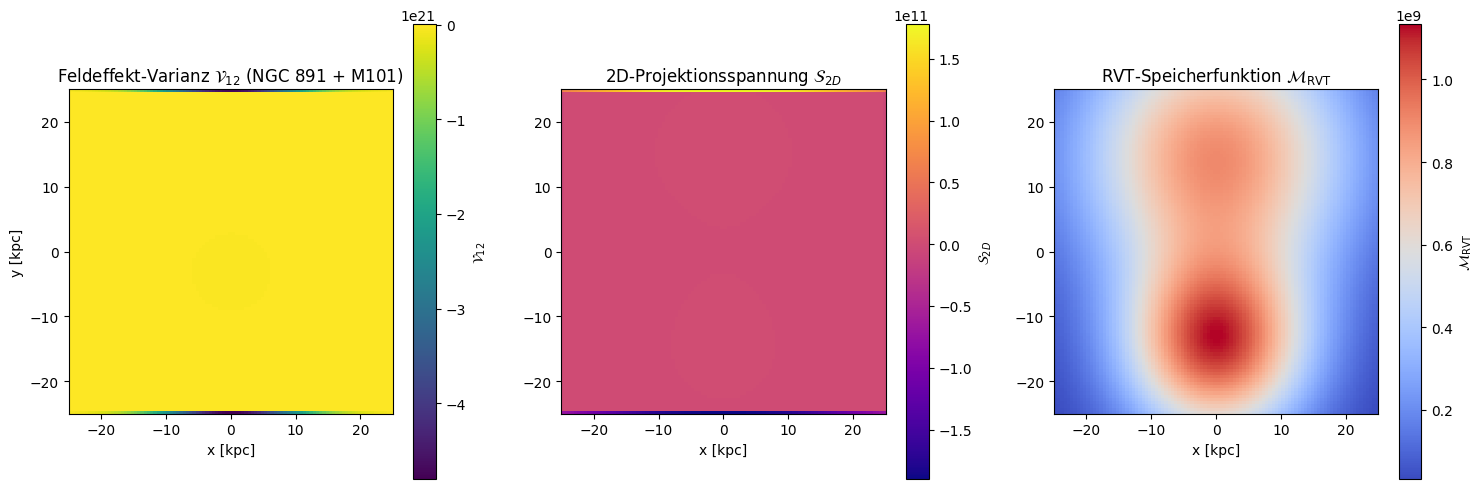

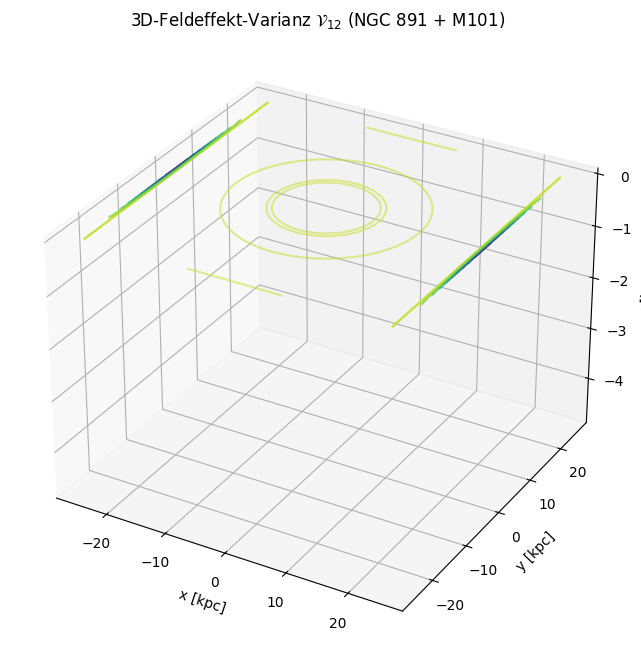

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter ---
N = 100  # Gitterpunkte
L = 50.0  # Systemgröße in kpc (ausreichend groß für Galaxien)
alpha = 0.8  # RVT-Kopplungskonstante
chi = 1.0    # Kopplungskonstante für M_RVT

# --- Beobachtete Daten für NGC 891 und M101 ---
# NGC 891 (Edge-on):
# - Masse: ~5e10 M_Sun (Baryonische Masse)
# - Skalenlänge: ~10 kpc (Radius)
# M101 (Face-on):
# - Masse: ~1e11 M_Sun (Baryonische Masse)
# - Skalenlänge: ~15 kpc (Radius)
# Quelle: de Blok et al. (2008), THINGS Survey

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) ---
# NGC 891: Zentrum bei (-15, 0, 0), Skalenlänge 10 kpc
Xi_1 = 5e10 * np.exp(-((X + 15)**2 + Y**2 + Z**2) / (2 * 10**2))
# M101: Zentrum bei (15, 0, 0), Skalenlänge 15 kpc
Xi_2 = 1e11 * np.exp(-((X - 15)**2 + Y**2 + Z**2) / (2 * 15**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_NGC891_M101.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurfaces in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurfaces für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')

plt.savefig('RVT_Varianz_3D_NGC891_M101.png', dpi=300)
plt.show()

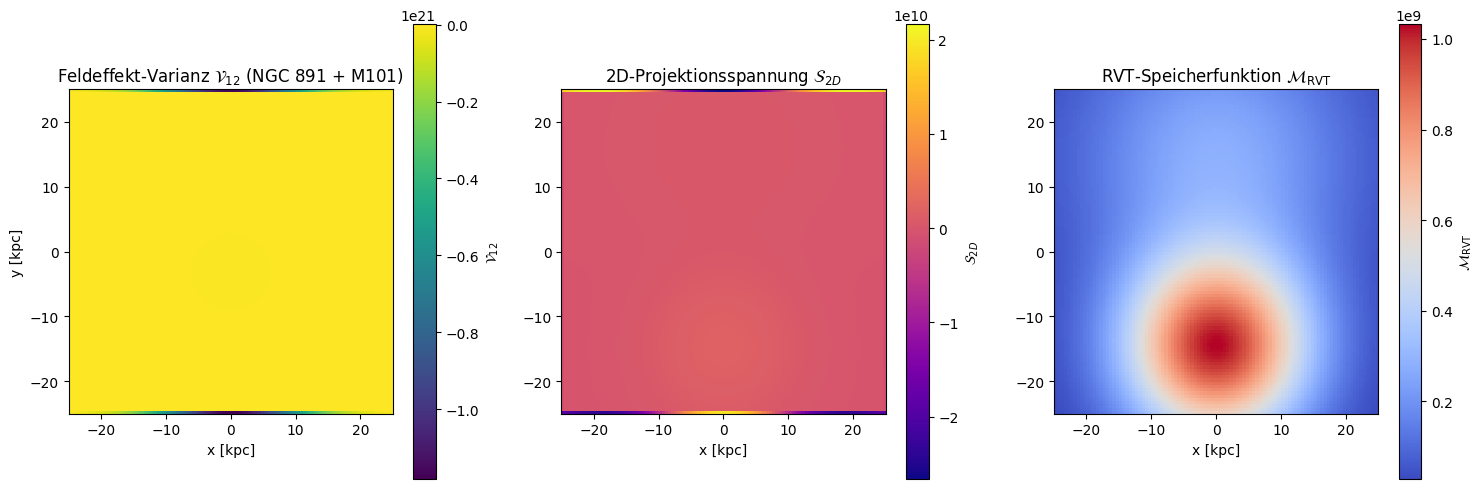

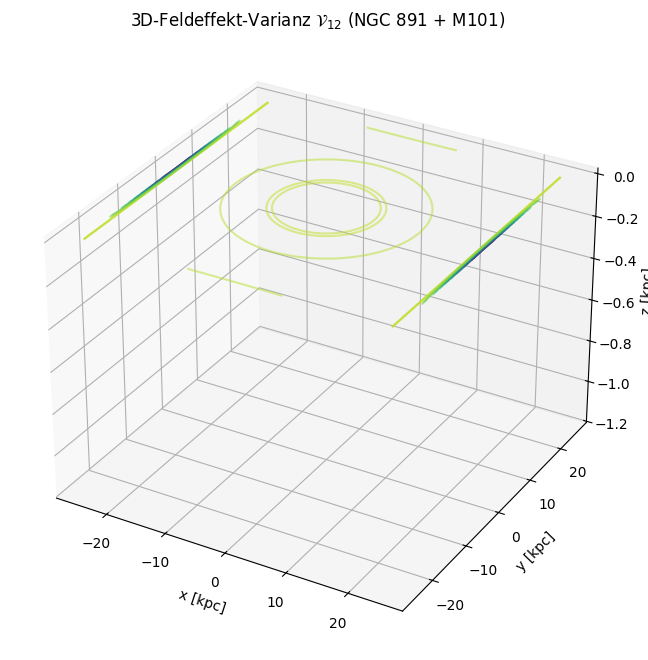

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter ---
N = 100  # Gitterpunkte
L = 50.0  # Systemgröße in kpc
C_RVT = 0.8  # RVT-Kopplungskonstante

# --- Inklinationswinkel (aus Beobachtungen) ---
# NGC 891: 85° (Edge-on)
# M101: 18° (Face-on)
inclination_891 = np.radians(85)
inclination_M101 = np.radians(18)

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) ---
# NGC 891: Zentrum bei (-15, 0, 0), Skalenlänge 10 kpc, Inklination 85°
# Projektion auf 2D-Äther: Skalierung mit sin(inclination)
Xi_1 = 5e10 * np.exp(-((X + 15)**2 + Y**2 + Z**2) / (2 * 10**2)) * np.sin(inclination_891)

# M101: Zentrum bei (15, 0, 0), Skalenlänge 15 kpc, Inklination 18°
Xi_2 = 1e11 * np.exp(-((X - 15)**2 + Y**2 + Z**2) / (2 * 15**2)) * np.sin(inclination_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) mit Kopplungsfaktor ---
V_12 = 2 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_Inklination_NGC891_M101.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurfaces in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurfaces für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')

plt.savefig('RVT_Varianz_3D_Inklination_NGC891_M101.png', dpi=300)
plt.show()

# Neuer Abschnitt

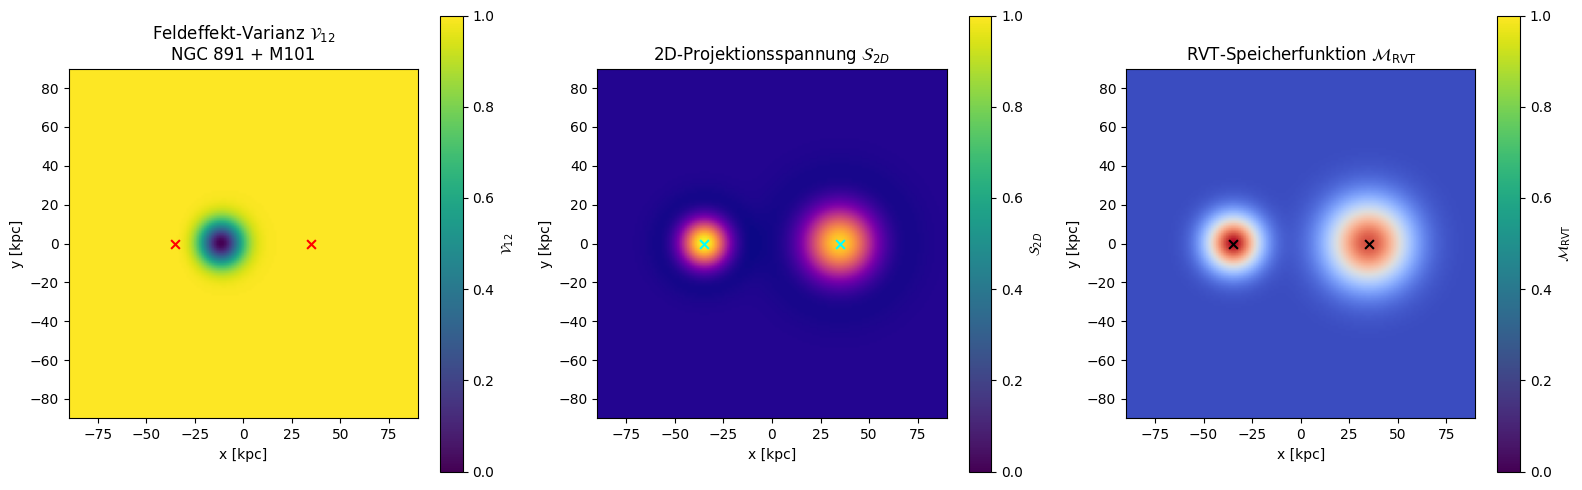

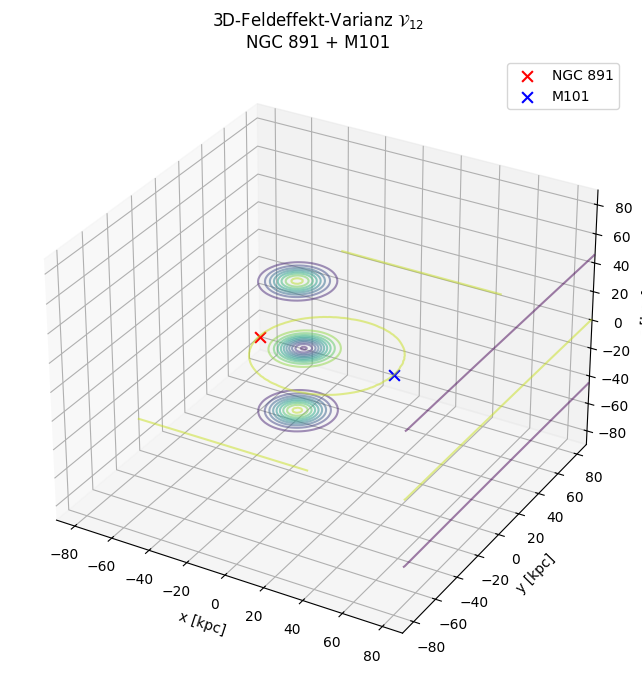

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 2: RVT-Feldeffekt-Varianz für NGC 891 + M101
# Ohne explizite Inklinationsskalierung
# ============================================================

# --- Parameter ---
N = 140          # Gitterpunkte; vorher 100
L = 180.0        # Systemgröße in kpc; Fenster: [-90, +90] kpc
alpha = 0.8      # RVT-Kopplungskonstante
chi = 1.0        # Kopplungskonstante für M_RVT

# --- Galaxienparameter ---
# NGC 891: Edge-on-Galaxie
M_891 = 5e10          # baryonische Masse in M_sun, Näherungswert
scale_891 = 10.0      # Skalenlänge in kpc
center_891 = (-35.0, 0.0, 0.0)

# M101: Face-on-Galaxie
M_M101 = 1e11         # baryonische Masse in M_sun, Näherungswert
scale_M101 = 15.0     # Skalenlänge in kpc
center_M101 = (35.0, 0.0, 0.0)

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

Xi_1 = gaussian_field(M_891, scale_891, center_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 ---
V_12 = 2.0 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$' + '\nNGC 891 + M101')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{M}_{\mathrm{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\mathrm{RVT}}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$' + '\nNGC 891 + M101')
ax.legend()

plt.savefig('RVT_Varianz_3D_NGC891_M101_grid180.png', dpi=300)
plt.show()


gamma_RVT(NGC 891, 85°) = 1.797
gamma_RVT(M101,    18°) = 1.247


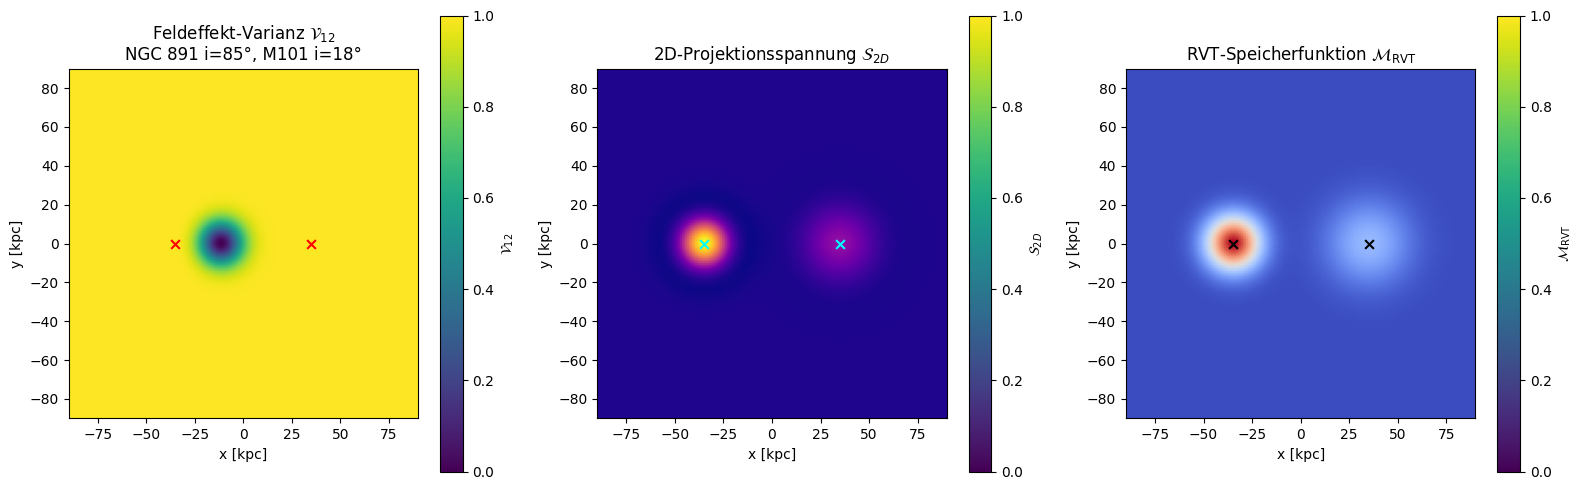

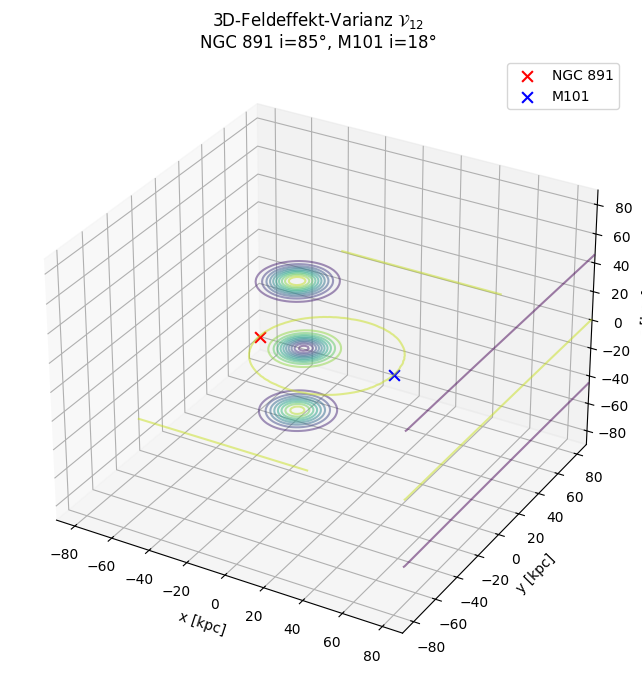

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 3: RVT-Feldeffekt-Varianz mit Inklinationsskalierung
# NGC 891: 85°
# M101:    18°
# ============================================================

# --- Parameter ---
N = 140           # Gitterpunkte; vorher 100
L = 180.0         # Systemgröße in kpc; Fenster: [-90, +90] kpc
C_RVT = 0.8       # RVT-Kopplungskonstante

# --- Galaxienparameter ---
M_891 = 5e10
scale_891 = 10.0
center_891 = (-35.0, 0.0, 0.0)

M_M101 = 1e11
scale_M101 = 15.0
center_M101 = (35.0, 0.0, 0.0)

# --- Inklinationswinkel ---
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

# --- RVT-Gamma-Korrektur ---
gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"gamma_RVT(NGC 891, {inclination_891_deg:.0f}°) = {gamma_891:.3f}")
print(f"gamma_RVT(M101,    {inclination_M101_deg:.0f}°) = {gamma_M101:.3f}")

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder mit Inklinationsskalierung ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

# Originale Inklinationsprojektion:
# Feld wird mit sin(i) gewichtet.
Xi_1 = gaussian_field(M_891, scale_891, center_891) * np.sin(inclination_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101) * np.sin(inclination_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 mit RVT-Kopplungsfaktor ---
V_12 = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(
    r'Feldeffekt-Varianz $\mathcal{V}_{12}$'
    + '\nNGC 891 i=85°, M101 i=18°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{M}_{\mathrm{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\mathrm{RVT}}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(
    r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$'
    + '\nNGC 891 i=85°, M101 i=18°'
)
ax.legend()

plt.savefig('RVT_Varianz_3D_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()


Zielausrichtung gamma_RVT(90°)      = 1.800
gamma_RVT(NGC 891, 85°)             = 1.797
gamma_RVT(M101, 18°)                = 1.247
relative Funnel-Amplitude Normal NGC 891 = 1.000
relative Funnel-Amplitude Normal M101    = 1.000
relative Funnel-Amplitude Incl NGC 891   = 0.998
relative Funnel-Amplitude Incl M101      = 0.693


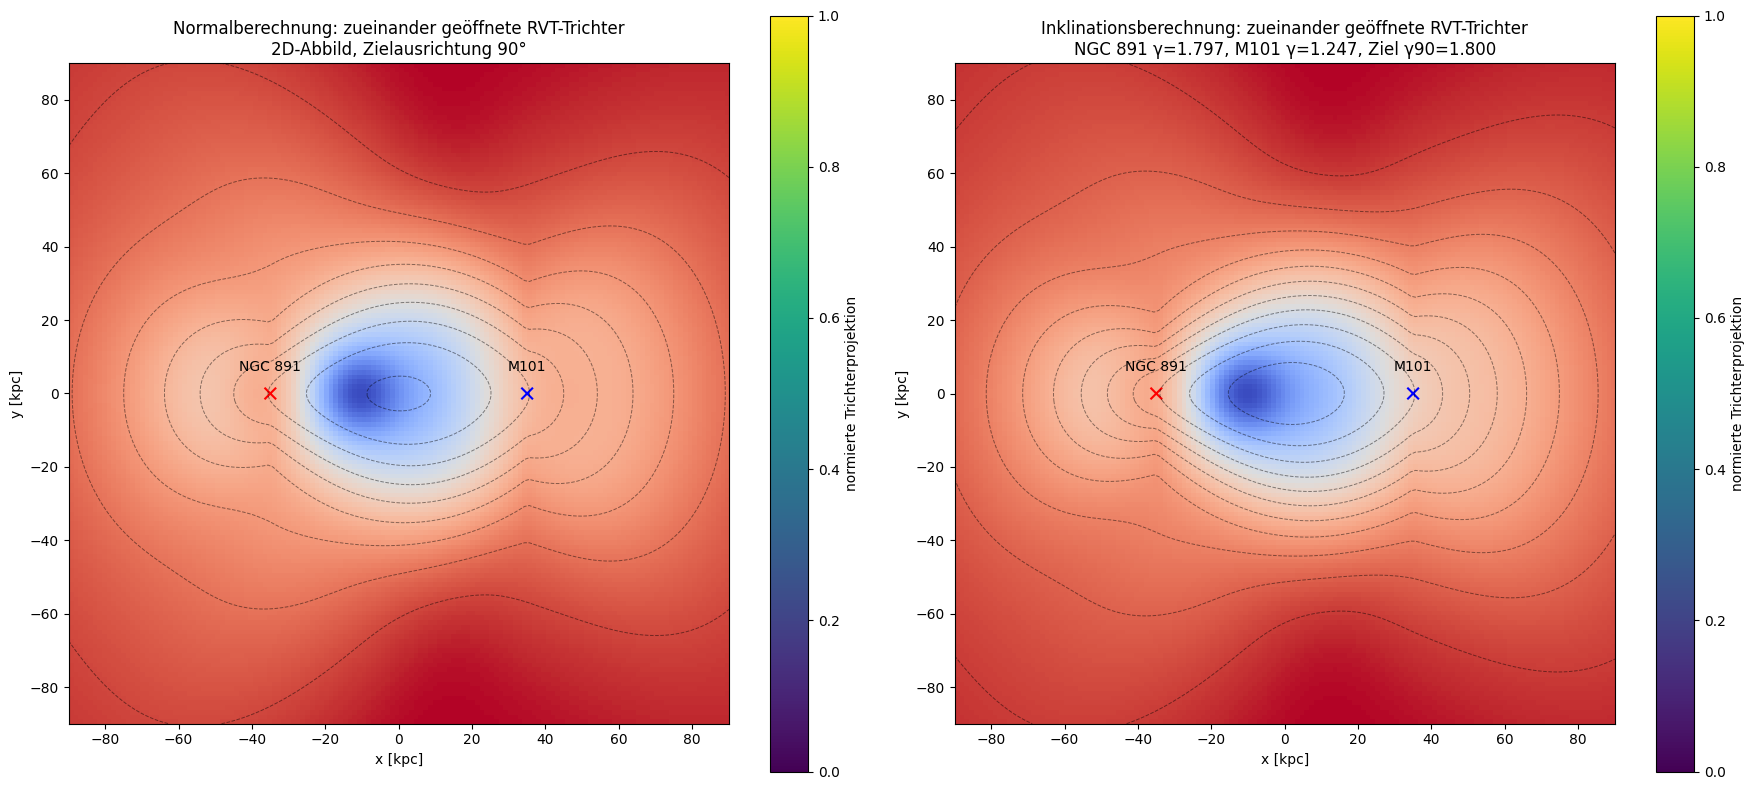

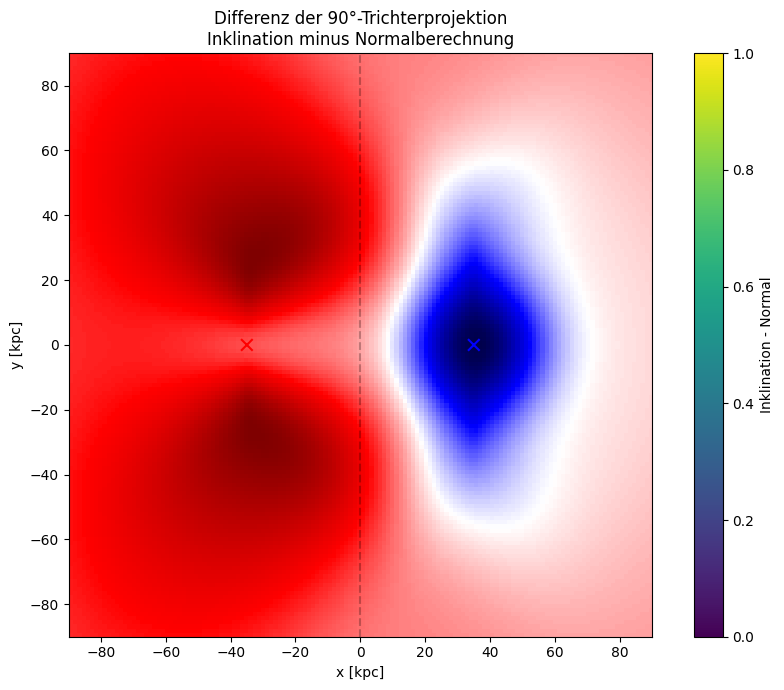

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion
# Vergleich:
# 1. Normalberechnung
# 2. Inklinationsberechnung
#
# Ziel:
# Zwei zueinander geöffnete 2D-Trichter bei 90°-Ausrichtung
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# Galaxienparameter
M_891 = 5e10
scale_891 = 10.0
center_891 = (-35.0, 0.0, 0.0)

M_M101 = 1e11
scale_M101 = 15.0
center_M101 = (35.0, 0.0, 0.0)

# Beobachtete Inklinationen
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"Zielausrichtung gamma_RVT(90°)      = {gamma_90:.3f}")
print(f"gamma_RVT(NGC 891, 85°)             = {gamma_891:.3f}")
print(f"gamma_RVT(M101, 18°)                = {gamma_M101:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    """
    Liefert V_12 und M_RVT für gegebene Felder.
    """
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung
# ------------------------------------------------------------
Xi_891_normal = gaussian_field(M_891, scale_891, center_891)
Xi_M101_normal = gaussian_field(M_M101, scale_M101, center_M101)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_891_normal,
    Xi_M101_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung
# ------------------------------------------------------------
Xi_891_incl = gaussian_field(M_891, scale_891, center_891) * gamma_891
Xi_M101_incl = gaussian_field(M_M101, scale_M101, center_M101) * gamma_M101

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_891_incl,
    Xi_M101_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width_left,
    width_right,
    length_scale,
    target_angle=np.pi / 2,
):
    """
    Erzeugt zwei zueinander geöffnete 2D-Trichter.

    Linker Trichter:
        Zentrum links, Öffnung nach rechts.

    Rechter Trichter:
        Zentrum rechts, Öffnung nach links.

    Die 90°-Ausrichtung wird als volle tangentiale Öffnung
    über sin(target_angle) eingebaut.
    """

    xL, yL = center_left
    xR, yR = center_right

    # Koordinaten relativ zu den Zentren
    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    # Öffnungsgewicht bei Zielwinkel 90°
    opening = np.sin(target_angle)

    # Linker Trichter öffnet nach rechts:
    # Nur Bereich x >= xL wird stark geöffnet.
    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))

    # Rechter Trichter öffnet nach links:
    # Nur Bereich x <= xR wird stark geöffnet.
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Radiale Trichterbreite wächst mit Entfernung vom Zentrum.
    # Dadurch entsteht die "aufgehende" Trichterform.
    radial_width_L = width_left * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width_right * (1.0 + np.abs(XR) / length_scale)

    # Trichterprofile
    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    # Gesamttrichter: beide öffnen zueinander
    funnel_total = funnel_L + funnel_R

    return funnel_total, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_891_2d = (center_891[0], center_891[1])
center_M101_2d = (center_M101[0], center_M101[1])

# ------------------------------------------------------------
# Amplituden aus den berechneten RVT-Werten ableiten
# ------------------------------------------------------------
def robust_amp(A):
    """
    Robuste Amplitude:
    nimmt 99%-Perzentil statt Maximum,
    damit einzelne numerische Spitzen nicht alles dominieren.
    """
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

# Normierung für saubere Darstellung
amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

# Relative RVT-Skalierung
# Normalfall: beide Trichter gleich aus der Feldamplitude.
amp_891_normal = amp_normal
amp_M101_normal = amp_normal

# Inklinationsfall:
# auf 90°-Zielausrichtung bezogen.
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

print(f"relative Funnel-Amplitude Normal NGC 891 = {amp_891_normal:.3f}")
print(f"relative Funnel-Amplitude Normal M101    = {amp_M101_normal:.3f}")
print(f"relative Funnel-Amplitude Incl NGC 891   = {amp_891_incl:.3f}")
print(f"relative Funnel-Amplitude Incl M101      = {amp_M101_incl:.3f}")

# ------------------------------------------------------------
# Trichter erzeugen
# ------------------------------------------------------------
width_891 = scale_891
width_M101 = scale_M101
length_scale = 28.0

funnel_normal, funnel_891_normal, funnel_M101_normal = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_normal,
    amp_M101_normal,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

funnel_incl, funnel_891_incl, funnel_M101_incl = opposing_funnel_2d(
    X2,
    Y2,
    center_891_2d,
    center_M101_2d,
    amp_891_incl,
    amp_M101_incl,
    width_891,
    width_M101,
    length_scale,
    target_angle=target_angle,
)

# ------------------------------------------------------------
# Kombinierte Karten:
# Trichter wird mit V_12 + M_RVT gekoppelt.
# ------------------------------------------------------------
def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(18, 8))

# Normaltrichter
plt.subplot(1, 2, 1)
plt.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_normal,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Normalberechnung: zueinander geöffnete RVT-Trichter\n'
    '2D-Abbild, Zielausrichtung 90°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Inklinationstrichter
plt.subplot(1, 2, 2)
plt.imshow(
    incl_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_incl,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center')
plt.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center')
plt.colorbar(label='normierte Trichterprojektion')
plt.title(
    'Inklinationsberechnung: zueinander geöffnete RVT-Trichter\n'
    f'NGC 891 γ={gamma_891:.3f}, M101 γ={gamma_M101:.3f}, Ziel γ90={gamma_90:.3f}'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Normal_vs_Inklination_NGC891_M101.png', dpi=300)
plt.show()

# ------------------------------------------------------------
# Differenzkarte
# ------------------------------------------------------------
difference_projection = incl_projection - normal_projection

plt.figure(figsize=(9, 7))
plt.imshow(
    difference_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='seismic',
    aspect='equal'
)
plt.scatter(
    [center_891[0], center_M101[0]],
    [center_891[1], center_M101[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.axvline(0, color='black', alpha=0.25, linestyle='--')
plt.colorbar(label='Inklination - Normal')
plt.title(
    'Differenz der 90°-Trichterprojektion\n'
    'Inklination minus Normalberechnung'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.tight_layout()
plt.savefig('RVT_Trichter_90deg_Differenz_NGC891_M101.png', dpi=300)
plt.show()
